In [2]:
# Cell 1: Load MNIST tự động qua TensorFlow/Keras + preprocessing
import os, time, random
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

SEED = 42
def seed_everything(s=42):
    random.seed(s); os.environ['PYTHONHASHSEED']=str(s)
    np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
seed_everything(SEED); os.makedirs("outputs", exist_ok=True)

# TỰ ĐỘNG TẢI MNIST BẰNG KERAS
import tensorflow as tf
(X_tr_full, y_tr_full), (X_te, y_te) = tf.keras.datasets.mnist.load_data()

# Chuẩn hóa dữ liệu về khoảng [0, 1] và thêm chiều channel
X_tr_full = (X_tr_full.astype(np.float32) / 255.0)[..., np.newaxis] # (60000, 28, 28, 1)
X_te = (X_te.astype(np.float32) / 255.0)[..., np.newaxis]           # (10000, 28, 28, 1)

# Chia tập Train / Validation
X_tr, X_val, y_tr, y_val = train_test_split(X_tr_full, y_tr_full,
                                            test_size=0.1, random_state=SEED, stratify=y_tr_full)

# Chuyển về dạng (N, Channel, Height, Width) cho PyTorch
X_tr = X_tr.transpose(0, 3, 1, 2)   # (N, 1, 28, 28)
X_val = X_val.transpose(0, 3, 1, 2)
X_te = X_te.transpose(0, 3, 1, 2)

print(f"Train/Val/Test: {X_tr.shape}/{X_val.shape}/{X_te.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train/Val/Test: (54000, 1, 28, 28)/(6000, 1, 28, 28)/(10000, 1, 28, 28)


In [3]:
# Cell 2: Conv2D từ scratch + ReLU + MaxPool2D + Dense + Softmax CE
class Conv2D:
    def __init__(self, in_ch, out_ch, k=3, stride=1, pad=1, seed=42):
        rng = np.random.default_rng(seed)
        limit = np.sqrt(2.0/(in_ch*k*k))
        self.W = (rng.standard_normal((out_ch, in_ch, k, k))*limit).astype(np.float32)
        self.b = np.zeros(out_ch, dtype=np.float32)
        self.stride, self.pad, self.k = stride, pad, k
        self.dW = np.zeros_like(self.W); self.db = np.zeros_like(self.b)
    def forward(self, X):
        self.X = X; self.X_pad = np.pad(X, ((0,0),(0,0),(self.pad,self.pad),(self.pad,self.pad)))
        N, C, H, W = X.shape
        H_out = (H + 2*self.pad - self.k)//self.stride + 1
        W_out = (W + 2*self.pad - self.k)//self.stride + 1
        out = np.zeros((N, self.W.shape[0], H_out, W_out), dtype=np.float32)
        for i in range(H_out):
            for j in range(W_out):
                s_i = i*self.stride; s_j = j*self.stride
                patch = self.X_pad[:, :, s_i:s_i+self.k, s_j:s_j+self.k]
                out[:, :, i, j] = np.tensordot(patch, self.W, axes=([1,2,3],[1,2,3])) + self.b
        return out
    def backward(self, dout):
        N, C_out, H_out, W_out = dout.shape
        self.db = dout.sum(axis=(0,2,3))
        self.dW = np.zeros_like(self.W)
        dX_pad = np.zeros_like(self.X_pad)
        for i in range(H_out):
            for j in range(W_out):
                s_i = i*self.stride; s_j = j*self.stride
                patch = self.X_pad[:, :, s_i:s_i+self.k, s_j:s_j+self.k]
                g = dout[:, :, i, j]
                self.dW += np.tensordot(g, patch, axes=([0],[0]))
                dX_pad[:, :, s_i:s_i+self.k, s_j:s_j+self.k] += np.tensordot(g, self.W, axes=([1],[0]))
        return dX_pad[:, :, self.pad:-self.pad, self.pad:-self.pad] if self.pad>0 else dX_pad

class ReLU2D:
    def forward(self, X): self.mask = X>0; return X*self.mask
    def backward(self, dout): return dout*self.mask

class MaxPool2D:
    def __init__(self, size=2, stride=2): self.size, self.stride = size, stride
    def forward(self, X):
        self.X = X; N,C,H,W = X.shape
        Ho = (H-self.size)//self.stride + 1; Wo = (W-self.size)//self.stride + 1
        out = np.zeros((N,C,Ho,Wo), dtype=np.float32)
        self.argmax = {}
        for i in range(Ho):
            for j in range(Wo):
                s_i = i*self.stride; s_j = j*self.stride
                patch = X[:,:,s_i:s_i+self.size, s_j:s_j+self.size].reshape(N,C,-1)
                out[:,:,i,j] = patch.max(axis=2)
                self.argmax[(i,j)] = patch.argmax(axis=2)
        return out
    def backward(self, dout):
        N,C,Ho,Wo = dout.shape
        dX = np.zeros_like(self.X)
        for i in range(Ho):
            for j in range(Wo):
                s_i = i*self.stride; s_j = j*self.stride
                am = self.argmax[(i,j)]
                for n in range(N):
                    for c in range(C):
                        u,v = divmod(am[n,c], self.size)
                        dX[n,c,s_i+u, s_j+v] += dout[n,c,i,j]
        return dX

class Dense2D:
    def __init__(self, in_f, out_f, seed=42):
        rng = np.random.default_rng(seed)
        self.W = (rng.standard_normal((in_f, out_f))*np.sqrt(2.0/in_f)).astype(np.float32)
        self.b = np.zeros((1,out_f), dtype=np.float32)
        self.dW = np.zeros_like(self.W); self.db = np.zeros_like(self.b)
    def forward(self, X): self.X = X; return X @ self.W + self.b
    def backward(self, dout):
        self.dW = self.X.T @ dout; self.db = dout.sum(axis=0, keepdims=True)
        return dout @ self.W.T

def softmax_ce(logits, labels):
    z = logits - logits.max(axis=1, keepdims=True)
    p = np.exp(z) / np.exp(z).sum(axis=1, keepdims=True)
    N = len(labels)
    loss = -np.log(np.clip(p[np.arange(N), labels], 1e-9, 1.0)).mean()
    dlogits = p.copy(); dlogits[np.arange(N), labels] -= 1; dlogits /= N
    return loss, dlogits

print("Đã định nghĩa NumPy CNN 2D.")

Đã định nghĩa NumPy CNN 2D.


In [4]:
# Cell 3: PyTorch CNN variants M1-M4
import torch.nn as nn
class SEBlock2D(nn.Module):
    def __init__(self, ch, r=8):
        super().__init__()
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(nn.Linear(ch, ch//r), nn.ReLU(),
                                nn.Linear(ch//r, ch), nn.Sigmoid())
    def forward(self, x):
        b,c,_,_ = x.size()
        s = self.fc(self.gap(x).view(b,c)).view(b,c,1,1)
        return x * s

class ResBlock2D(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.body = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1), nn.BatchNorm2d(ch), nn.ReLU(),
            nn.Conv2d(ch, ch, 3, padding=1), nn.BatchNorm2d(ch))
        self.relu = nn.ReLU()
    def forward(self, x): return self.relu(x + self.body(x))

class MNISTCNN(nn.Module):
    def __init__(self, variant=1, n_classes=10):
        super().__init__()
        use_bn = variant>=2; use_res = variant>=3; use_se = variant>=4
        def blk(ci,co):
            L=[nn.Conv2d(ci,co,3,padding=1)]
            if use_bn: L.append(nn.BatchNorm2d(co))
            L.append(nn.ReLU()); return nn.Sequential(*L)
        self.stem = blk(1,32); self.pool = nn.MaxPool2d(2)
        self.res = ResBlock2D(32) if use_res else nn.Identity()
        self.se  = SEBlock2D(32) if use_se  else nn.Identity()
        self.mid = blk(32,64); self.pool2 = nn.MaxPool2d(2)
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Dropout(0.25),
            nn.Linear(64*7*7, 128), nn.ReLU(),
            nn.Linear(128, n_classes))
    def forward(self, x):
        x = self.pool(self.stem(x))
        x = self.se(self.res(x))
        x = self.pool2(self.mid(x))
        return self.classifier(x)
print("Đã định nghĩa MNIST CNN variants.")

Đã định nghĩa MNIST CNN variants.


In [5]:
# Cell 4: Train 4 variants
X_tr_t = torch.tensor(X_tr); y_tr_t = torch.tensor(y_tr, dtype=torch.long)
X_val_t = torch.tensor(X_val); y_val_t = torch.tensor(y_val, dtype=torch.long)
X_te_t = torch.tensor(X_te); y_te_t = torch.tensor(y_te, dtype=torch.long)

def make_loader(X,y,bs,sh):
    return DataLoader(TensorDataset(X,y), batch_size=bs, shuffle=sh)

tr_ld = make_loader(X_tr_t, y_tr_t, 128, True)
val_ld = make_loader(X_val_t, y_val_t, 256, False)

def train_mnist(model, epochs=6, lr=1e-3):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device); crit = nn.CrossEntropyLoss()
    opt = optim.Adam(model.parameters(), lr=lr)
    hist = {'loss':[], 'val_acc':[]}
    t0 = time.time()
    for ep in range(epochs):
        model.train(); tl, n = 0., 0
        for xb, yb in tr_ld:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(); out = model(xb); loss = crit(out, yb)
            loss.backward(); opt.step()
            tl += loss.item()*len(yb); n += len(yb)
        model.eval(); corr, vn = 0, 0
        with torch.no_grad():
            for xb, yb in val_ld:
                xb, yb = xb.to(device), yb.to(device)
                corr += (model(xb).argmax(1)==yb).sum().item(); vn += len(yb)
        hist['loss'].append(tl/n); hist['val_acc'].append(corr/vn)
        print(f"Epoch {ep+1}/{epochs} | loss={tl/n:.4f} | val_acc={corr/vn:.4f}")
    return hist, time.time()-t0

results = {}
for v, name in zip([1,2,3,4], ['M1 Baseline','M2 +BN','M3 +Res','M4 +SE']):
    seed_everything(SEED)
    m = MNISTCNN(variant=v)
    hist, t = train_mnist(m, epochs=6)
    n_p = sum(p.numel() for p in m.parameters())
    m.eval()
    with torch.no_grad():
        pred = m(X_te_t).argmax(1).numpy()
    test_acc = (pred == y_te).mean()
    results[name] = {'test_acc':test_acc,'params':n_p,'time':t,'hist':hist,'model':m}
    print(f"{name} — Test Acc: {test_acc:.4f} | Params: {n_p} | {t:.1f}s")

Epoch 1/6 | loss=0.2762 | val_acc=0.9752
Epoch 2/6 | loss=0.0682 | val_acc=0.9830
Epoch 3/6 | loss=0.0493 | val_acc=0.9842
Epoch 4/6 | loss=0.0394 | val_acc=0.9845
Epoch 5/6 | loss=0.0310 | val_acc=0.9870
Epoch 6/6 | loss=0.0268 | val_acc=0.9882
M1 Baseline — Test Acc: 0.9911 | Params: 421642 | 143.7s
Epoch 1/6 | loss=0.1463 | val_acc=0.9828
Epoch 2/6 | loss=0.0536 | val_acc=0.9860
Epoch 3/6 | loss=0.0406 | val_acc=0.9853
Epoch 4/6 | loss=0.0330 | val_acc=0.9848
Epoch 5/6 | loss=0.0280 | val_acc=0.9877
Epoch 6/6 | loss=0.0226 | val_acc=0.9868
M2 +BN — Test Acc: 0.9904 | Params: 421834 | 168.6s
Epoch 1/6 | loss=0.1400 | val_acc=0.9843
Epoch 2/6 | loss=0.0447 | val_acc=0.9817
Epoch 3/6 | loss=0.0376 | val_acc=0.9847
Epoch 4/6 | loss=0.0281 | val_acc=0.9890
Epoch 5/6 | loss=0.0240 | val_acc=0.9875
Epoch 6/6 | loss=0.0200 | val_acc=0.9885
M3 +Res — Test Acc: 0.9930 | Params: 440458 | 239.1s
Epoch 1/6 | loss=0.1291 | val_acc=0.9685
Epoch 2/6 | loss=0.0469 | val_acc=0.9862
Epoch 3/6 | loss=0

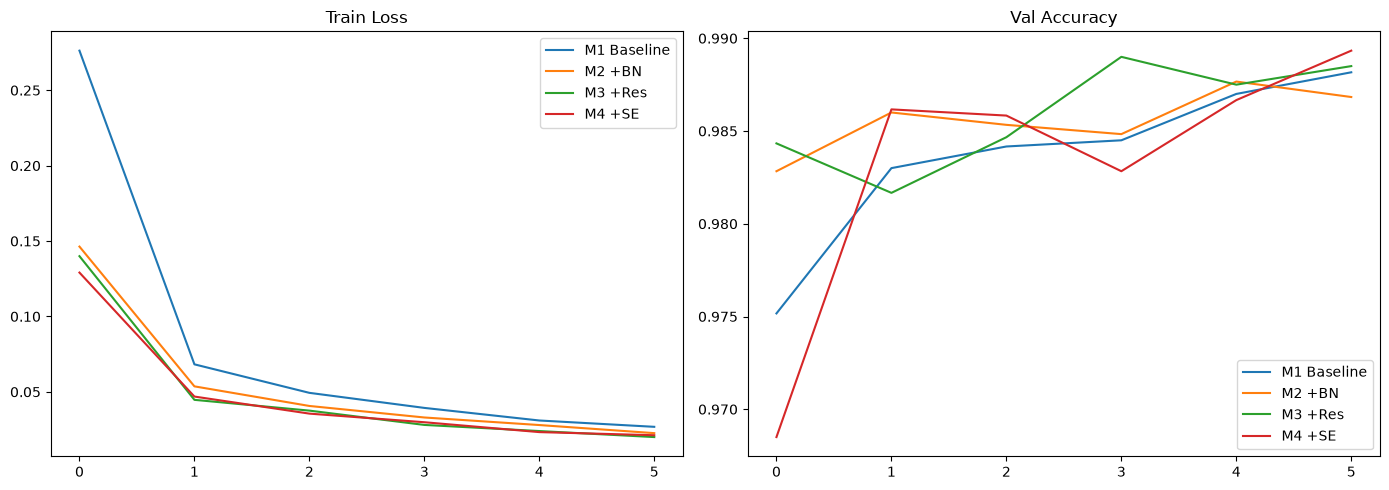

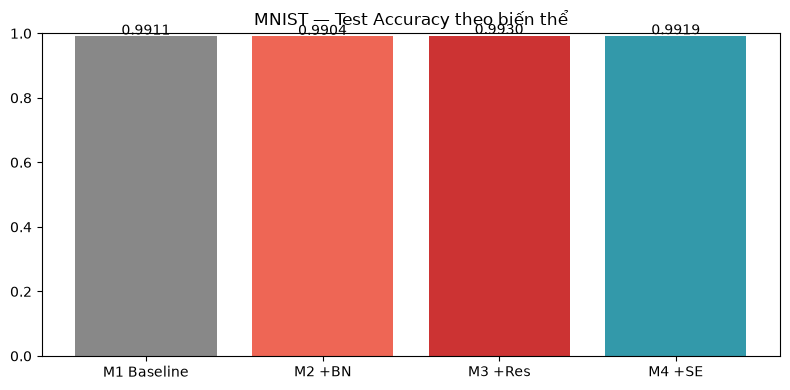

In [6]:
# Cell 5: Curves + comparison bar
fig, axes = plt.subplots(1,2,figsize=(14,5))
for name, r in results.items():
    axes[0].plot(r['hist']['loss'], label=name)
    axes[1].plot(r['hist']['val_acc'], label=name)
axes[0].set_title("Train Loss"); axes[0].legend()
axes[1].set_title("Val Accuracy"); axes[1].legend()
plt.tight_layout(); plt.savefig("outputs/mnist_ablation_curves.png", dpi=200); plt.show()

plt.figure(figsize=(8,4))
names = list(results.keys())
accs = [results[n]['test_acc'] for n in names]
plt.bar(names, accs, color=['#888','#e65','#c33','#39a'])
for i,a in enumerate(accs): plt.text(i, a+0.005, f"{a:.4f}", ha='center')
plt.ylim(0,1); plt.title("MNIST — Test Accuracy theo biến thể")
plt.tight_layout(); plt.savefig("outputs/mnist_ablation_bar.png", dpi=200); plt.show()

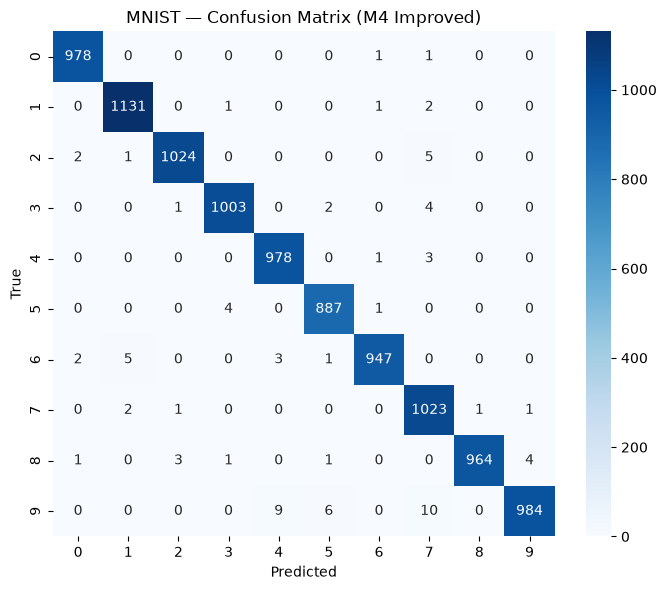

              precision    recall  f1-score   support

           0     0.9949    0.9980    0.9964       980
           1     0.9930    0.9965    0.9947      1135
           2     0.9951    0.9922    0.9937      1032
           3     0.9941    0.9931    0.9936      1010
           4     0.9879    0.9959    0.9919       982
           5     0.9889    0.9944    0.9916       892
           6     0.9958    0.9885    0.9921       958
           7     0.9761    0.9951    0.9855      1028
           8     0.9990    0.9897    0.9943       974
           9     0.9949    0.9752    0.9850      1009

    accuracy                         0.9919     10000
   macro avg     0.9920    0.9919    0.9919     10000
weighted avg     0.9920    0.9919    0.9919     10000



In [7]:
# Cell 6: Confusion Matrix của M4
best = results['M4 +SE']['model']
best.eval()
with torch.no_grad():
    pred = best(X_te_t).argmax(1).numpy()
cm = confusion_matrix(y_te, pred)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("MNIST — Confusion Matrix (M4 Improved)")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout(); plt.savefig("outputs/mnist_confusion.png", dpi=200); plt.show()
print(classification_report(y_te, pred, digits=4))